## Supplementary Material:

This notebook is used to fit the A-Scaling descriptive variables ($\theta$, $a_i$, $b_i$, $c_i$, and $d_i$) for each pure fluid (n-hexane, cyclopentyl methyl ether, and propan-1-ol) and their liquid viscosity as a function of temperature and the liquid viscosity for n-hexane + cyclopentyl methyl ether + propan-1-ol ternary mixture at 298.15 K and 101.3 kPa using the A-Scaling theory coupled to SAFT-VR Mie EoS proposed by Lafitte et al. 

This notebook uses an external Excel file (experimental_data.xlsx) which contains the experimental data and the SGTPy suite, which is free download at https://pypi.python.org/pypi/sgtpy/

For further details, the reader is redirected to “Thermophysical characterization of the synthetic oxygenate fuel mixture formed by hexane + cyclopentyl methyl ether + propan-1-ol” by Isaías Huenuvil-Pacheco, Marcela Cartes and Andrés Mejía submitted to the ChemSusChem Journal.

In [1]:
import math
from scipy import integrate
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt
from sgtpy import component, mixture, saftvrmie


In [2]:

hexane = component('hexane', ms = 1.96720036, sigma = 4.54762477, eps = 377.60127994, 
                   lambda_r = 18.41193194, lambda_a = 6.0, cii = 3.581510586936205e-19 )

cpme = component('cpme', ms = 2.34183523, sigma = 4.12538522, eps = 344.80694006, lambda_r = 14.1775199,
                 lambda_a = 6.0, sites = [0,0,1], cii = 3.516252062709723e-19)

propanol = component('propanol', ms = 2.2513, sigma = 3.6008 , eps = 253.45,
                    lambda_r = 11.960, lambda_a = 6., eAB = 2794.88, rcAB = 0.3481,sites=[1,0,1], cii= 8.67969723e-20)

In [29]:
'''
This code is connected to SGTPy module to describe the properties of pure fluid and get the parameters of 
SAFT-VR Mie (i.e epsilon, Mw, lambda, etc)
'''

def visc_hs(component, T):
    '''
    calculate the dynamic viscosity of a hard-sphere fluid.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object
    T: temperature in K

    Returns
    -------
    visc: dynamic viscosity in mPa*s
    '''
    
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    
    Tr = T/(component.eps/kb)
    
    #Collision integral
    def Omega(Tr):    
        term1 = 1.16145/Tr**0.14874
        term2 = 0.52487/np.exp(0.7732*Tr)
        term3 = 2.16178/np.exp(2.43787*Tr)
        term4 = 6.435e-04*Tr**0.14874*math.sin(18.0323*Tr**(-0.7683)-7.27371)
        return term1 + term2 + term3 - term4    # Neufeld et al.'s empirical correlation    
    
    visc = 5/16 * np.sqrt(component.Mw/1000*kb*T/Na)/component.sigma**2/Omega(Tr)*1000 # Chapman-Enskog equation for the viscosity of a hard-sphere gas
    
    return visc

def CMie(component):
    '''
    calculate parameter C in the Mie potential for a pure component.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object
    Returns
    -------
    C: C-parameter (dimensionless)
    '''
    
    CMie = component.lambda_r/(component.lambda_r-component.lambda_a)*(component.lambda_r/component.lambda_a)**(component.lambda_a/(component.lambda_r-component.lambda_a))
    
    return CMie


def deff(component, T):
    '''
    calculate the effective diameter according to Barker-Henderson's perturbation theory for soft-core potentials.
    
    Parameters
    ----------
    component : object
        :class:`SGTPy.component` object
    T: temperature in K

    Returns
    -------
    deff: effective diameter in meter
    '''
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    
    umie = lambda r: CMie(component)*(component.eps/kb)*((component.sigma/r)**component.lambda_r-(component.sigma/r)**component.lambda_a)
    func = lambda r: 1-np.exp(-1/T*umie(r))
    deff = integrate.quadrature(func, 0.0, component.sigma)
    
    return deff


In [4]:

def Ascaling(C, component, T, P):

    '''
    Parameters
    ----------
    C : A-Scaling parameter vector for pure compounds (optimized)
            C[0]: Theta, 
            C[1], C[2], C[3], C[4] : a, b, c, d (described in article)

    component : object
        :class:`SGTPy.component` object
    T : temperature in K 
    P : pressure in Pa

    Returns
    ---------
    visc :  Viscosity of pure compounds according to A-Scaling theory
    '''
    
    
    kb = 1.3806488e-23  # Boltzman's constant, J/K
    Na = 6.022142e23  # Avogadro's number, mol^{-1}
    R = Na*kb
        
    eos = saftvrmie(component)
    
    rhol = eos.density(T, P, 'L') # density
            
    vres = 1/rhol-R*T/P   # residual volume
            
    sres = eos.EntropyR(T, P, 'L') # residual entropy
            
    hres = eos.EnthalpyR(T, P, 'L') # residual enthalpy
            
    ares = (hres-P*vres-T*sres)/R/T # residual Helmholtz energy 
            
    d = deff(component, T)
            
    rholn = rhol*Na
            
    rhos = rholn*component.ms
    
    eta = rhos*math.pi*d[0]**3/6
            
    areshs = (4*eta-3*eta**2)/(1-eta)**2
            
    vischs = visc_hs(component, T)
            
    da = ares-areshs
            
    Tr = T/(component.eps/kb)
        
    f = Tr**C[0]
    visc = (np.exp(C[1]+C[2]*(f*da)+C[3]*(f*da)**2+C[4]*(f*da)**3))*vischs
        
    return visc

    
        


## Objective function to obtain A-Scaling parameters

In [54]:
def optimization(component, Texp, P, viscexp,c0 = [0, 0, 0, 0, 0]):
    '''
    Parameters : 
    ------------

    component : object
        :class:`SGTPy.component` object
    Texp : experimental temperature in K 
    P : pressure in Pa
    viscexp : experimental viscosities in mPa/s

    c0 : A-Scaling parameter vector for pure compounds initial guess
            C[0]: Theta, 
            C[1], C[2], C[3], C[4] : a, b, c, d (described in article)

    Returns
    ---------
    
    C : Optimized A-Scaling Theory parameters

    
    '''
    
    if len(Texp) == len(Texp):

        def fobj (C,component, Texp, P, viscexp):
            n = len(Texp)
            visc = np.zeros_like(Texp)
            for i in range(n):
                visc [i] = Ascaling(C, component, Texp[i], P)
            error = 1 / n * np.sum(abs(visc - viscexp) / viscexp)
            return error  
        
        fit = minimize(fobj, c0, args = (component, Texp, P, viscexp), method = 'Nelder-Mead',  options={
        'xatol': 1e-8,      
        'fatol': 1e-8,      
        'maxiter': 10000,   
        'maxfev': 20000 })
           
    else:
        print('Error: The length of the temperature and viscosity vectors are different')
    
    return fit

    

In [6]:
df = pd.read_excel('experimental_data.xlsx', 'visc_hexane')
viscHex_exp = np.asarray(df.iloc[:, 2])  #  mPa s
Texp_Hexpure = np.asarray(df.iloc[:, 0])

df = pd.read_excel('experimental_data.xlsx', 'visc_cpme')
viscCPME_exp = np.asarray(df.iloc[:, 2])  #  mPa s
Texp_CPMEpure = np.asarray(df.iloc[:, 0])

df = pd.read_excel('experimental_data.xlsx', 'visc_propanol')
viscprop_exp = np.asarray(df.iloc[:, 2])  #  mPa s
Texp_proppure = np.asarray(df.iloc[:, 0])


In [78]:
''' Optimization of parameters to begin of experimental data of pure components 
'''

parameters_hexane = optimization(hexane, Texp_Hexpure, P, viscHex_exp, c0 = [7.01963598e-01,  3.65147283e+00, -3.22651482e-01, -1.41276326e-03,-1.06320374e-03])
parameters_cpme = optimization(cpme, Texp_CPMEpure, P, viscCPME_exp, c0 = [1.77330926,  1.40658274, -2.0590878 , -0.50640353, -0.0519143])
parameters_propanol = optimization(propanol,  Texp_proppure, P, viscprop_exp, c0 = [1.87408881,  0.57528125, -1.46032921, -0.18667662, -0.01061123])
parameters_hexane.x

In [72]:
''' Optimized parameters for pure components
'''

C_hexane = np.array([6.97610452e-01,  3.65239335e+00, -3.22445828e-01, -1.55586807e-03,-1.07243487e-03])
C_cpme = np.array([ 1.77269383,  1.40387416, -2.05960217, -0.50612411, -0.05185475 ])
C_propanol = np.array([1.90057166,  0.5860076 , -1.45731764, -0.18734802, -0.01067735 ])


n = 100
T = np.linspace(273, 350, 100 )

P = 101325

visco1 = np.zeros(len(Texp_Hexpure))
visco2 = np.zeros(len(Texp_CPMEpure))
visco3 = np.zeros(len( Texp_proppure))

visco1 = [Ascaling(C_hexane, hexane, T, P) for T in Texp_Hexpure]
visco2 = [Ascaling(C_cpme, cpme, T, P) for T in Texp_CPMEpure]
visco3 = [Ascaling(C_propanol, propanol, T, P) for T in Texp_proppure]

errorvischex = 100. * np.mean(np.abs(visco1/viscHex_exp - 1))
errorvisccpme = 100. * np.mean(np.abs(visco2/viscCPME_exp - 1))
errorviscprop = 100. * np.mean(np.abs(visco3/viscprop_exp - 1))

print('Hexane error viscosity:', errorvischex)
print('CPME error viscosity:', errorvisccpme)
print('Propanol error viscosity:', errorviscprop)

C:\Users\isaia\AppData\Local\Temp\ipykernel_19240\2791469891.py:74: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


Hexane error viscosity: 0.0010734433420054514
CPME error viscosity: 0.05835656271627812
Propanol error viscosity: 0.058087784684870664


(0.0, 2.5)

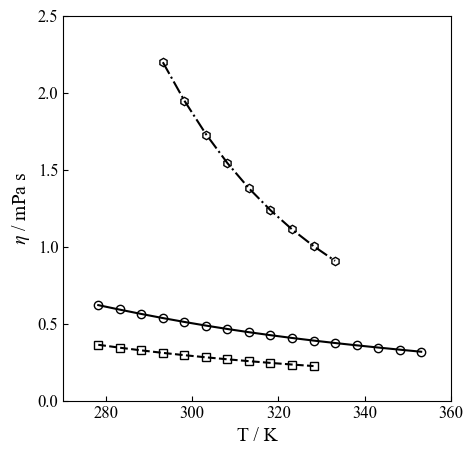

In [69]:
plt.rc('text', usetex=False )

plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fontsize = 14

fig = plt.figure(figsize = (5,5))
lw = 1.5
plt.plot(Texp_Hexpure, visco1,'--', color = 'black',linewidth=lw)
plt.plot(Texp_Hexpure, viscHex_exp, 's',color = 'k',mfc='none')

plt.plot(Texp_CPMEpure, visco2,color = 'black',linewidth=lw)
plt.plot(Texp_CPMEpure, viscCPME_exp, 'ok',mfc='none')

plt.plot(Texp_proppure, visco3,'-.',color = 'black',linewidth=lw)
plt.plot(Texp_proppure, viscprop_exp, 'hk',mfc='none')



plt.tick_params(direction='in')

plt.xlabel("T / K",fontsize=fontsize)
plt.ylabel(r"$\eta$ / mPa s", fontsize=fontsize)
plt.xlim(270,360)
plt.ylim(0.0,2.5)


In [60]:
# Helmholtz Scaling Theory for Ternary system 

def viscoternary_Ascaling(component1,component2,component3,T,P,X,matcoeff1,matcoeff2,matcoeff3):

    import math
    import numpy as np
    from scipy.constants import k, Avogadro, R
    
    
    Na = Avogadro
    R = k * Na
    kb = k
    mix = component1+component2+component3

    
    components = np.array([component1,component2,component3])
    
    
   # setting up interaction corrections
    Kij = np.array([[0., k12, k13], [k12, 0., k23], [k13, k23, 0.]])
    Lij = np.array([[0., l12, l13], [l12, 0., l23], [l13, l23, 0.]])
    mix.kij_saft(Kij)
    mix.lij_saft(Lij)

    eos = saftvrmie(mix) 
    c = eos.nc

    eos.eABij[2,0] = propanol.eAB / 2
    eos.eABij[0,2] = propanol.eAB / 2
    eos.rcij[2,0] = rc13 * 1e-10
    eos.rcij[0,2] = rc13 * 1e-10

    eos.eABij[2,1] = propanol.eAB / 2
    eos.eABij[1,2] = propanol.eAB / 2
    eos.rcij[2,1] = rc23 * 1e-10
    eos.rcij[1,2] = rc23 * 1e-10
    
    
    theta = np.array([matcoeff1[0],matcoeff2[0],matcoeff3[0]])
    coeff_pure = np.array([matcoeff1,matcoeff2,matcoeff3])
    coeff_pure = np.delete(coeff_pure, 0, axis=1)  #Eliminar primera columna de theta (solo coeff)
        
    rhol = eos.density(X, T, P, 'L')
    vres = 1/rhol-R*T/P
    sres = eos.EntropyR(X, T, P, 'L')
    hres = eos.EnthalpyR(X, T, P, 'L')
    ares = (hres-P*vres-T*sres)/R/T
    
    xs = np.zeros(c)
    
    for i in range(c):
        sum_deno = sum(components[j].ms *X[j] for j in range(c))
        xs [i] = components[i].ms*X[i]/sum_deno

    rholn = rhol*Na
    rhos = rholn*sum(components[i].ms*X[i] for i in range(c))
    
    d11 = deff(component1, T)  #effective diameter
    d22 = deff(component2, T)
    d33 = deff(component3, T)
    
    dii = np.array([d11[0],d22[0],d33[0]])
    
    zeta0 = math.pi*rhos/6
    zeta1 = math.pi*rhos/6*sum(xs[i]*dii[i] for i in range(c))
    zeta2 = math.pi*rhos/6*sum(xs[i]*dii[i]**2 for i in range(c))
    zeta3 = math.pi*rhos/6*sum(xs[i]*dii[i]**3 for i in range(c))
    
    areshs = (1/zeta0)*(3*zeta1*zeta2/(1-zeta3)+zeta2**3/(zeta3*(1-zeta3)**2)+(zeta2**3/zeta3**2-zeta0)*np.log(1-zeta3))
    da = ares-areshs

    Tr = np.zeros(c)
    f = np.zeros(c)
    for i in range(c):
        Tr[i] = T/(components[i].eps/kb)
        f [i] = Tr[i]**theta[i] 
    
    avgm = sum(X[i]*components[i].ms for i in range(c))
    
    coeff_mix = np.zeros(4)  
    for i in range(4):
        coeff_mix [i] = sum(X[j]*coeff_pure[j,i]*(f[j]*components[j].ms/avgm*da)**i for j in range(c))
    sum_coeff_mix = np.sum(coeff_mix)

    phi = np.zeros([3,3])
    eta_hs = 0
    eta = np.zeros(c)

    for i in range(c):
        eta[i] = visc_hs(components[i], T)
    
    for i in range(c):
        for j in range(c):
            phi[i][j] = (1 + np.sqrt(eta[i] / eta[j]) * (components[j].Mw /components[i].Mw))**2 / np.sqrt(8 * (1 + components[i].Mw / components[j].Mw))
        sum_phi = sum(X[j] * phi[i][j] for j in range(c))
        eta_hs += X[i]*eta[i] / sum_phi
    
    visc_model = np.exp(sum_coeff_mix)*eta_hs
    
    return visc_model

In [73]:
# reading excel file
df = pd.read_excel('experimental_data.xlsx', 'viscosity')
# reading dataframe data
Texp = np.asarray(df.iloc[:, 0])  # K
Pexp = np.asarray(df.iloc[:, 1], dtype=float)  # Pa
# liquid phase composition
xhexane = np.asarray(df.iloc[:, 2])
xcpme = np.asarray(df.iloc[:, 3])
xpropanol = np.asarray(df.iloc[:, 4])
Xexp = np.array([xhexane, xcpme, xpropanol])
print(np.shape(Xexp))
# liquid density
rho_exp = np.asarray(df.iloc[:, 6])  #kg/m3
# liquid viscosity
visc_exp = np.asarray(df.iloc[:, 5])  #  mPa s
df.head()


(3, 41)


,T / K,P / Pa,xHexane,xCPME,xPropanol,m_lab,rho_g/cm3,rho_g/cm3.1
0,298.15,101325,0.090337,0.101900,0.807763,1.154,787.713311,0.787713
1,298.15,101325,0.084394,0.205837,0.709769,0.953,798.157454,0.798157
2,298.15,101325,0.087503,0.297349,0.615148,0.811,805.362463,0.805362
3,298.15,101325,0.082225,0.401875,0.515900,0.708,813.793103,0.813793
4,298.15,101325,0.088598,0.522156,0.389246,0.608,819.407008,0.819407


In [82]:
k12, l12 = np.array([ 0.00295, 0]) # hexane (1) cpme (2)
k13, l13 = np.array([ 4.227e-03, 0]) # hexane (1) propanol (3)
k23, l23 = np.array([ 0.0123,  0]) # cpme (2) propanol (3) with rcAB

rc12 = 0
rc13 = 1.312e+00
rc23 = 2.206   #rc induced association



Xexp = np.array([xhexane, xcpme, xpropanol])
n = len(Xexp[0])

visc_model = np.zeros_like(Xexp[0])

comp = [hexane, cpme, propanol]

for i in range(n):
    visc_model[i] = viscoternary_Ascaling(hexane,cpme,propanol, Texp[i], Pexp[i], Xexp[:,i], C_hexane, C_cpme,C_propanol)
    
errorvisc = 100. * np.mean(np.abs(visc_model/visc_exp - 1))
print('Error viscosity:', errorvisc)

C:\Users\isaia\AppData\Local\Temp\ipykernel_19240\2791469891.py:74: DeprecationWarning: `scipy.integrate.quadrature` is deprecated as of SciPy 1.12.0and will be removed in SciPy 1.15.0. Please use`scipy.integrate.quad` instead.
  deff = integrate.quadrature(func, 0.0, component.sigma)


Error viscosity: 2.057755828821658


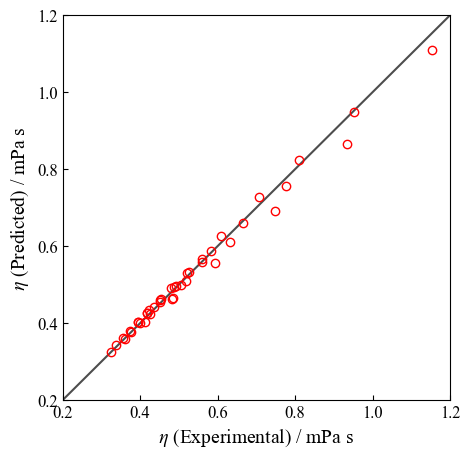

In [83]:
plt.rc('text', usetex=False )

plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fontsize = 14

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)

ax.plot([0, 1.2], [0, 1.2], c = '0.3')
ax.plot(visc_exp, visc_model, 'o', color = 'red',mfc = 'none')


ax.set_ylabel(r'$\eta$ (Predicted) / mPa s', fontsize=fontsize)

ax.set_xlabel(r'$\eta$ (Experimental) / mPa s', fontsize=fontsize)


lim = [0.2, 1.2]
ax.set_xlim(lim)
ax.set_ylim(lim)

ax.tick_params(direction='in')


In [ ]:
n = 5000
x1 = np.linspace(0,1,n)
x2m = np.zeros(n)
x3m = np.zeros(n)

for i in range(n):
    x2 = np.random.uniform(0,1-x1[i])
    x3 = 1-x1[i]-x2
    x2m[i] = x2
    x3m[i] = x3
    #print(x1[i],x2m[i],x3m[i], 'suma =', x1[i]+x2m[i]+x3m[i])
    suma = x1[i]+x2m[i]+x3m[i]
   # if suma != 1:
        #print('suma diferente de 1')

X = np.array([x1, x2m, x3m])


T = 298.15
P = 101325

visc_mod = np.zeros(n)

for i in range(n):
    visc_mod[i] = viscoternary_Ascaling(hexane, cpme, propanol, T, P, X[:,i],  C_hexane, C_cpme,C_propanol)

C:\Users\isaia\AppData\Local\Temp\ipykernel_19240\53507698.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')


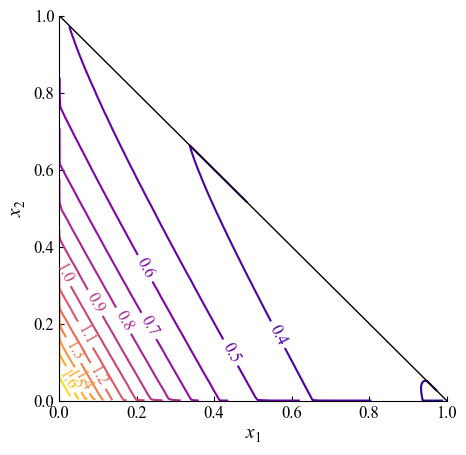

In [33]:
fig = plt.figure(figsize=(5, 5))


ax = fig.add_subplot(1, 1, 1)
cmap = plt.cm.get_cmap('plasma')
cs = ax.tricontour(x1, x2m, visc_mod,levels = 15,cmap=cmap)
ax.clabel(cs)
ax.plot([1,0],[0,1],color='k',linewidth=1)

ax.set_xlabel(r'$x_1$',fontsize=fontsize)  #
ax.set_ylabel(r'$x_2$',fontsize=fontsize)  # 
ax.set_xlim(0,1)
ax.set_ylim(0,1)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(direction='in')

plt.show()